# Profiling results — NumPy vs JAX-CPU vs JAX-GPU

Visualise the Kaiser-Bessel imaging profiling. This notebook **auto-loads** every
`*_profile.txt` in the results folder, so it works for any set of runs — change
`n_freqs`, `n_times`, `Npx`, or the backend in the job, re-run, and re-execute here.

Backends: `NumPy` (pure NumPy), `jaxCPU`, `jaxGPU`. Each run writes
`test_Npx{N}_tt{T}_nt{nt}_nf{nf}_{backend}_test_{tracking|vis_sampling}_profile.txt`,
whose first line reports the wall time (`... in X seconds`).

In [1]:
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = "out_jz"          # folder holding the *_profile.txt files (auto-scanned)
N_BASELINES = 702          # vlac array: 27 antennas -> 27*26 = 702 baselines

# Colours match profiling/results.ipynb
BACKENDS = ["NumPy", "jaxCPU", "jaxGPU"]
COLORS = {"NumPy": "deepskyblue", "jaxCPU": "teal", "jaxGPU": "mediumorchid"}

def parse_time(path):
    """Total wall time (s) from a cProfile text dump."""
    with open(path) as f:
        m = re.search(r"in ([0-9.]+) seconds", f.read())
    return float(m.group(1)) if m else np.nan

PAT = re.compile(
    r"test_Npx(\d+)_tt[\d.]+_nt(\d+)_nf(\d+)_(NumPy|jaxCPU|jaxGPU)_test_(tracking|vis_sampling)_profile\.txt"
)

In [2]:
# Auto-scan the output folder -> one row per configuration, one column per backend.
records = {}
for path in glob.glob(os.path.join(OUTDIR, "*_profile.txt")):
    m = PAT.search(os.path.basename(path))
    if not m:
        continue
    npx, nt, nf, backend, func = int(m[1]), int(m[2]), int(m[3]), m[4], m[5]
    records.setdefault((npx, nt, nf), {})[(func, backend)] = parse_time(path)

rows = []
for (npx, nt, nf), d in records.items():
    row = dict(npx=npx, n_times=nt, n_freqs=nf, n_vis=N_BASELINES * nt * nf)
    for b in BACKENDS:
        row[f"img_{b}"] = d.get(("vis_sampling", b), np.nan)
        row[f"trk_{b}"] = d.get(("tracking", b), np.nan)
    rows.append(row)
df = pd.DataFrame(rows).sort_values(["npx", "n_vis"]).reset_index(drop=True)
df["label"] = df.apply(lambda r: f"{r.n_vis/1e6:.1f}M vis", axis=1)

# Backends actually present in the data.
present = [b for b in BACKENDS if df[f"img_{b}"].notna().any()]
print(f"Auto-loaded {len(df)} configurations from {OUTDIR}/  |  backends: {present}")
df[["npx", "n_times", "n_freqs", "n_vis"] + [f"img_{b}" for b in present]]

Auto-loaded 3 configurations from out_jz/  |  backends: ['NumPy', 'jaxCPU', 'jaxGPU']


,npx,n_times,n_freqs,n_vis,img_NumPy,img_jaxCPU,img_jaxGPU
0,1024,360,16,4043520,113.795,2.976,0.184
1,1024,360,64,16174080,489.256,11.876,0.632
2,1024,360,128,32348160,1008.349,27.005,1.238


## Speedup table

Speedups relative to NumPy (if present), else relative to jaxCPU.

In [3]:
ref = "NumPy" if "NumPy" in present else "jaxCPU"
sp = df[["label", "n_vis"]].copy()
for b in present:
    sp[f"img_{b} (s)"] = df[f"img_{b}"]
for b in present:
    if b != ref:
        sp[f"{b} vs {ref}"] = df[f"img_{ref}"] / df[f"img_{b}"]
sp

,label,n_vis,img_NumPy (s),img_jaxCPU (s),img_jaxGPU (s),jaxCPU vs NumPy,jaxGPU vs NumPy
0,4.0M vis,4043520,113.795,2.976,0.184,38.237567,618.451087
1,16.2M vis,16174080,489.256,11.876,0.632,41.197036,774.139241
2,32.3M vis,32348160,1008.349,27.005,1.238,37.339345,814.498384


## Imaging time: backends compared

Grouped bars per configuration (deepskyblue = NumPy, teal = JAX-CPU,
mediumorchid = JAX-GPU). Log y-axis (times span orders of magnitude).

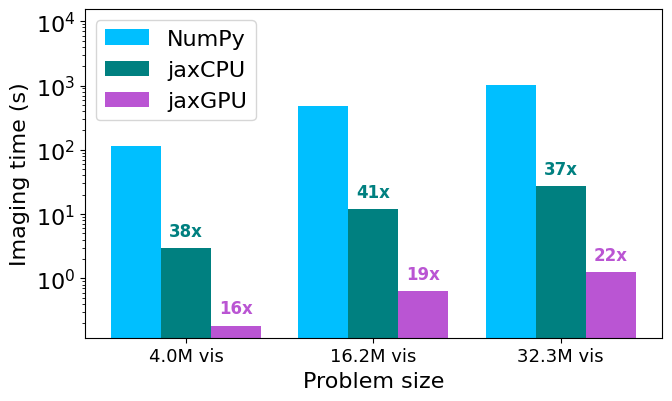

In [9]:
# Set fontsize to 16
plt.rcParams.update({'font.size': 16})
x = np.arange(len(df))
n = len(present); w = 0.8 / n
fig, ax = plt.subplots(figsize=(max(7, 1.9 * len(df)), 4.3))
for i, b in enumerate(present):
    ax.bar(x + (i - (n - 1) / 2) * w, df[f"img_{b}"], w, label=b, color=COLORS[b])
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(df.label, fontsize=13)
ax.set_ylabel("Imaging time (s)")
# ax.set_title("Imaging time by backend")
ax.legend()
# ax.grid(True, axis="y", which="both", alpha=0.3)

# Speedup annotations above each bar, over the backend to its left:
# jaxCPU vs NumPy, jaxGPU vs jaxCPU. Skipped where a value is missing.
SPEEDUP_REF = {"jaxCPU": "NumPy", "jaxGPU": "jaxCPU"}
for b, ref in SPEEDUP_REF.items():
    if b not in present or f"img_{ref}" not in df.columns:
        continue
    xoff = (present.index(b) - (n - 1) / 2) * w
    for xi in range(len(df)):
        t = df[f"img_{b}"].iloc[xi]
        rt = df[f"img_{ref}"].iloc[xi]
        if np.isfinite(t) and np.isfinite(rt):
            ax.text(x[xi] + xoff, t * 1.35, f"{rt / t:.0f}x",
                    ha="center", va="bottom", fontsize=12,
                    color=COLORS[b], fontweight="bold")
# Headroom for the top labels on the log axis.
ax.set_ylim(top=ax.get_ylim()[1] * 10)
ax.set_xlabel("Problem size")
plt.tight_layout() 
plt.savefig("jax_acceleration.pdf")
plt.show()